In [63]:
# IMPORTAR LIBRERÍAS NECESARIAS

# numpy: librería matemática por excelencia para manejar los datos numéricos.
import numpy as np

# matplotlib.pyplot: para hacer las gráficas (plots).
import matplotlib.pyplot as plt

# pathlib: para manejar rutas de carpetas y archivos. 
from pathlib import Path

# scipy.io: para abrir archivos de MATLAB
# h5py: para leer archivos .mat v7.3
import scipy.io as sio
from scipy.signal import butter, sosfiltfilt, hilbert, spectrogram
from scipy.interpolate import interp1d

import h5py

# pandas: para manejar datos en forma de tablas (dataframes).
import pandas as pd

In [51]:
# 1. PARÁMETROS DEL REGISTRO
n_channels = 16 # Número de canales del probe
fs = 2500       # Frecuencia de muestreo (Hz)

# 2. CARGAR EL ARCHIVO DE DATOS
carpeta_sesion = Path(r"D:\Violeta\ANALISIS\WT_90\2025_07_16_0000")

archivo_lfp_dat = carpeta_sesion / "LFP_downsampled.dat"
archivo_ripple_analysis = carpeta_sesion / "analyset" / "rippleAnalysis.mat"
archivo_csd = carpeta_sesion / "rippleCSDs.mat"

# Para comprobar que se encuentran los archivos 
if not archivo_lfp_dat.exists():
    print(f"No se encuentra el archivo .dat en:\n{archivo_lfp_dat}")
elif not archivo_ripple_analysis.exists():
    print(f"No se encuentra el archivo .mat en:\n{archivo_ripple_analysis}")
else:
    print("Archivos encontrados e identificados")
    print(f"Sesión activa: {carpeta_sesion.name}")

'''
# 2.1. CARGAR MÚLTIPLES ARCHIVOS DE DATOS
carpeta_principal = Path(r"D:\Violeta\ANALISIS")
sesiones_validas = []

# rglob() busca en TODAS las subcarpetas archivos que se llamen así
for dat_file in carpeta_principal.rglob("LFP_downsampled.dat"):
    folder_sesion = dat_file.parent
    mat_file = folder_sesion / "analyset" / "rippleAnalysis.mat"
    if mat_file.exists():
        sesiones_validas.append(folder_sesion)
        
print(f"Sesiones válidas encontradas en total: {len(sesiones_validas)}")
        
'''

print(f"Todo listo para analizar. \nFrecuencia: {fs} Hz \nCanales: {n_channels}")

Archivos encontrados e identificados
Sesión activa: 2025_07_16_0000
Todo listo para analizar. 
Frecuencia: 2500 Hz 
Canales: 16


<>:23: SyntaxWarning: "\V" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\V"? A raw string is also an option.
<>:23: SyntaxWarning: "\V" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\V"? A raw string is also an option.
C:\Users\natal\AppData\Local\Temp\ipykernel_12928\4185252564.py:23: SyntaxWarning: "\V" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\V"? A raw string is also an option.
  carpeta_principal = Path(r"D:\Violeta\ANALISIS")


In [5]:
# 3. LEER EL ARCHIVO DE DATOS
# En registros neuronales, el formato estándar de los datos suele ser un tipo de número llamado 'int16' (entero de 16 bits).
datos_brutos = np.fromfile(archivo_lfp_dat, dtype=np.int16)

print(f"Puntos totales leídos: {len(datos_brutos)}")

# Cortar la fila en bloques de 16 canales.
# El '-1' es un truco de Python que significa: "calcula tú cuántas filas salen, yo solo te fijo que hay {n_channels} columnas"
datos_matriz = datos_brutos.reshape(-1, n_channels)

# Extraer cuántos instantes de tiempo reales tenemos
puntos_de_tiempo = datos_matriz.shape[0]

print(f"LFP cargado correctamente.")
print(f"¡Éxito! Ahora hay una matriz con: {puntos_de_tiempo} filas (tiempo) y {datos_matriz.shape[1]} columnas (canales).")

Puntos totales leídos: 36632736
LFP cargado correctamente.
¡Éxito! Ahora hay una matriz con: 2289546 filas (tiempo) y 16 columnas (canales).


In [6]:
# 4. CREAR CARPETA DE RESULTADOS
# Poner nombre a la carpeta de resultados.
carpeta_resultados = carpeta_sesion / "ProcesamientoNatalia"

# Crearla físicamente en el disco duro.
# exist_ok=True significa que si ya existe (porque se ejecuta varias veces), no dará error.
carpeta_resultados.mkdir(exist_ok=True)

print(f"¡Carpeta lista! Todo se guardará en:\n{carpeta_resultados}")

¡Carpeta lista! Todo se guardará en:
D:\Violeta\ANALISIS\WT_90\2025_07_16_0000\ProcesamientoNatalia


In [13]:
# 5. SELECCIÓN DE LOS RIPPLE DETECTADOS
# Cargar el el archivo .mat que contiene la estructura rippleAnalysis
with h5py.File(archivo_ripple_analysis, 'r') as f:
    # Acceder a la estructura rippleAnalysis y extraer iRipsMiddle
    picos_matlab = f['rippleAnalysis']['iRipSMiddle'][:]

# Extraer la variable iRipsMiddle y le restamos 1 para ajustar a Python (base 0)
# Se usa .flatten() para convertirlo en una lista simple de números
picos_ripples = picos_matlab.flatten().astype(int) - 1
num_ripples = len(picos_ripples)

print(f"¡Éxito al cargar el archivo .mat!")
print(f"Se han detectado {num_ripples} ripples en esta sesión.")
print(f"El centro del primer ripple está en el punto: {picos_ripples[0]}")


¡Éxito al cargar el archivo .mat!
Se han detectado 270 ripples en esta sesión.
El centro del primer ripple está en el punto: 26142


In [59]:
# 6. CÁLCULO DE AMPLITUD MÁXIMA DE RIPPLE POR CANAL Y RIPPLE MEDIO

# Definir la ventana de 30 ms (75 puntos a 2500 Hz)
ventana_ms = 30
puntos_ventana = int((ventana_ms / 1000) * fs)  # 75 puntos a cada lado del centro
longitud_segmento = (puntos_ventana * 2) + 1  # Total de puntos en el segmento (151 puntos)

# Crear el vector tiempo en milisegundos (ventana de 30ms)
tiempo = np.linspace(-ventana_ms, ventana_ms, longitud_segmento)

# Recortar los ripples de la matriz de LFP
lista_ripples = []

for pico in picos_ripples:
    inicio = pico - puntos_ventana
    fin = pico + puntos_ventana + 1

    # Asegurarse de que el segmento no se salga de los límites de la matriz de datos
    if inicio >= 0 and fin <= puntos_de_tiempo:
        segmento = datos_matriz[inicio:fin, :]  # (151 puntos, 16 canales)
        lista_ripples.append(segmento)

# Convertir a un array de numpy para facilitar los cálculos
matriz_ripples = np.array(lista_ripples)  # (270 ripples, 151 puntos de tiempo, 16 canales)

## CÁLCULO DEL RIPPLE MEDIO POR CANAL ##
# Se promedia a lo largo de todos los ripples (axis=0)
ripple_medio = np.mean(matriz_ripples, axis=0)  # (151 puntos, 16 canales)

## CÁLCULO DE LA AMPLITUD DE CADA RIPPLE INDIVIDUAL EN CADA CANAL ##
# axis=1 es el tiempo (151 puntos) -> devuelve una matriz de (270 ripples, 16 canales)
amplitudes_por_ripple = np.ptp(matriz_ripples, axis=1)
# Amplitud mázima en cada canal
max_absoluta_por_canal = np.max(amplitudes_por_ripple, axis=0)
# Promedio de las amplitudes de todos los ripples en cada canal
promedio_indiv_por_canal = np.mean(amplitudes_por_ripple, axis=0) 
# Amplitud del ripple medio
amplitud_ripple_medio = np.ptp(ripple_medio, axis=0)

# Identificar el evento récord absoluto en la sesión (el máximo de todos los ripples y canales)
idx_ripple_max, idx_canal_max = np.unravel_index(np.argmax(amplitudes_por_ripple), amplitudes_por_ripple.shape)
# Variables explícitas de los récords
canal_record = idx_canal_max + 1
num_ripple_record = idx_ripple_max + 1
valor_record = amplitudes_por_ripple[idx_ripple_max, idx_canal_max]

# Guardarlo en CSV
df_resultados = pd.DataFrame({
    'Canal': [f"Canal_{i+1}" for i in range(n_channels)],
    'Amplitud_Maxima_Absoluta': max_absoluta_por_canal,
    'Amplitud_Promedio_Ripples': promedio_indiv_por_canal,
    'Amplitud_Ripple_Medio': amplitud_ripple_medio
})

ruta_csv = carpeta_resultados / "amplitud_maxima_por_canal.csv"
df_resultados.to_csv(ruta_csv, index=False)

print("="*65)
print("Métricas de amplitud calculadas y guardadas correctamente.")
print(f"Canal con mayor amplitud RÉCORD individual: Canal {canal_record}")
print(f"   └─ Ocurrió en el Ripple #{num_ripple_record} con una amplitud de {valor_record:.2f} uV")
print(f"Canal con mayor amplitud PROMEDIO por ripple: Canal {np.argmax(promedio_indiv_por_canal) + 1}")
print(f"\nTabla guardada con todas las columnas en:\n{ruta_csv}")
print("="*65)

Métricas de amplitud calculadas y guardadas correctamente.
Canal con mayor amplitud RÉCORD individual: Canal 13
   └─ Ocurrió en el Ripple #158 con una amplitud de 4569.00 uV
Canal con mayor amplitud PROMEDIO por ripple: Canal 13

Tabla guardada con todas las columnas en:
D:\Violeta\ANALISIS\WT_90\2025_07_16_0000\ProcesamientoNatalia\amplitud_maxima_por_canal.csv


<>:23: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:23: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\natal\AppData\Local\Temp\ipykernel_12928\47224664.py:23: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.xlabel('Amplitud ($\mu V$)', fontsize=10)


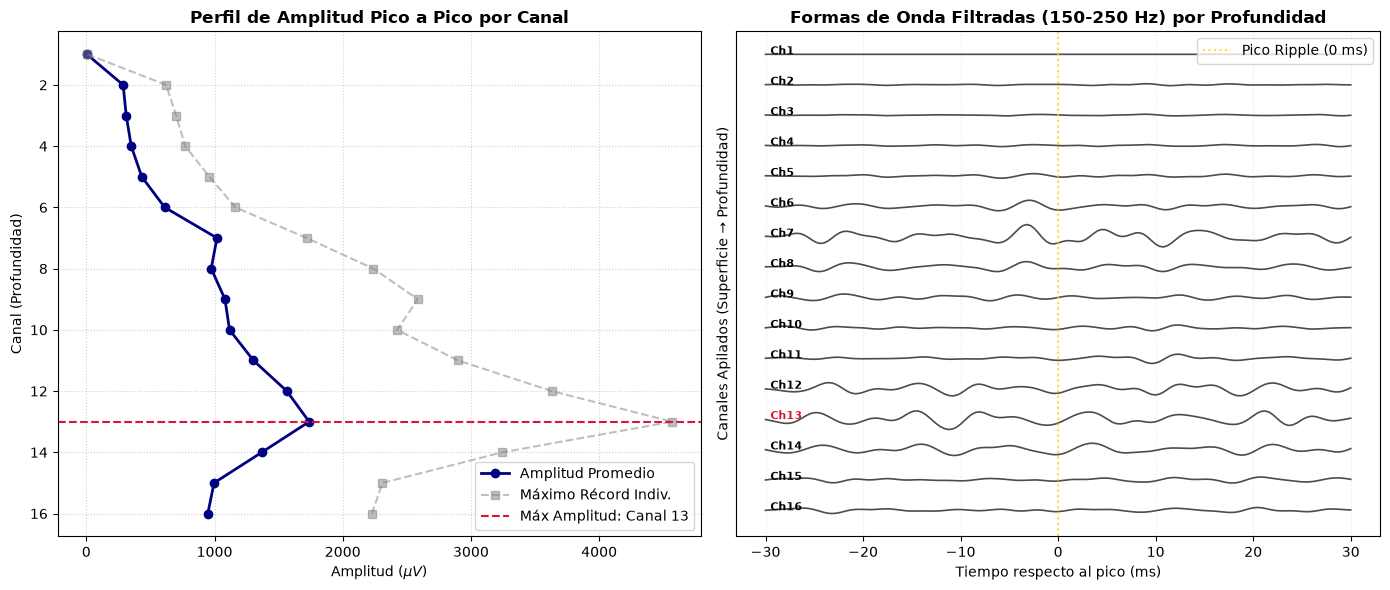

Gráfica de Amplitud y Formas de Onda guardada en:
D:\Violeta\ANALISIS\WT_90\2025_07_16_0000\ProcesamientoNatalia\perfil_amplitud_y_formas_de_onda.png


In [60]:
# FIGURA PARA AMPLITUD Y FORMAS DE ONDA
# Se filtra el Ripple Medio en la banda ripple para revelar las ondas rápidas
f_low, f_high = 100, 300
sos_ripple = butter(4, [f_low, f_high], btype='band', fs=fs, output='sos')
ripple_medio_filtrado = sosfiltfilt(sos_ripple, ripple_medio, axis=0)

plt.figure(figsize=(14, 6))

# --- SUBPLOT A: PERFIL DE AMPLITUD PICO A PICO POR CANAL ---
plt.subplot(1, 2, 1)
canales_eje = np.arange(1, n_channels + 1)

# Graficar la amplitud promedio por ripple y el récord máximo
plt.plot(promedio_indiv_por_canal, canales_eje, 'o-', color='navy', linewidth=2, label='Amplitud Promedio')
plt.plot(max_absoluta_por_canal, canales_eje, 's--', color='gray', alpha=0.5, label='Máximo Récord Indiv.')

# Canal top de amplitud (Canal 13)
canal_top_amp = np.argmax(promedio_indiv_por_canal) + 1
plt.axhline(y=canal_top_amp, color='crimson', linestyle='--', label=f'Máx Amplitud: Canal {canal_top_amp}')

plt.gca().invert_yaxis()  # Invertir eje Y para representar la profundidad real
plt.title('Perfil de Amplitud Pico a Pico por Canal', fontsize=12, fontweight='bold')
plt.xlabel('Amplitud ($\mu V$)', fontsize=10)
plt.ylabel('Canal (Profundidad)', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right')


# --- SUBPLOT B: FORMAS DE ONDA CORREGIDAS (TRACE PLOT) ---
plt.subplot(1, 2, 2)

# Se escala el desplazamiento entre trazas según la amplitud de la oscilación
amp_oscilacion = np.max(np.abs(ripple_medio_filtrado))
offset = amp_oscilacion * 2.5

for ch in range(n_channels):
    canal_num = ch + 1
    traza = ripple_medio_filtrado[:, ch] - (ch * offset)
    
    plt.plot(tiempo, traza, color='black', alpha=0.7, linewidth=1.2)
    
    plt.text(-29.5, -ch * offset, f'Ch{canal_num}', fontsize=8, fontweight='bold', 
             color='crimson' if canal_num == canal_top_amp else 'black')

plt.axvline(x=0, color='gold', linestyle=':', alpha=0.8, label='Pico Ripple (0 ms)')
plt.title('Formas de Onda Filtradas (150-250 Hz) por Profundidad', fontsize=12, fontweight='bold')
plt.xlabel('Tiempo respecto al pico (ms)', fontsize=10)
plt.ylabel('Canales Apilados (Superficie → Profundidad)', fontsize=10)
plt.yticks([])
plt.grid(True, linestyle=':', alpha=0.3)
plt.legend(loc='upper right')

plt.tight_layout()

# Guardar la figura en la carpeta ProcesamientoNatalia
ruta_figura_amp = carpeta_resultados / "perfil_amplitud_y_formas_de_onda.png"
plt.savefig(ruta_figura_amp, dpi=300)
plt.show()

print(f"Gráfica de Amplitud y Formas de Onda guardada en:\n{ruta_figura_amp}")

<>:26: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:26: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\natal\AppData\Local\Temp\ipykernel_12928\2580458541.py:26: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.ylabel('Voltaje ($\mu V$)', fontsize=10)


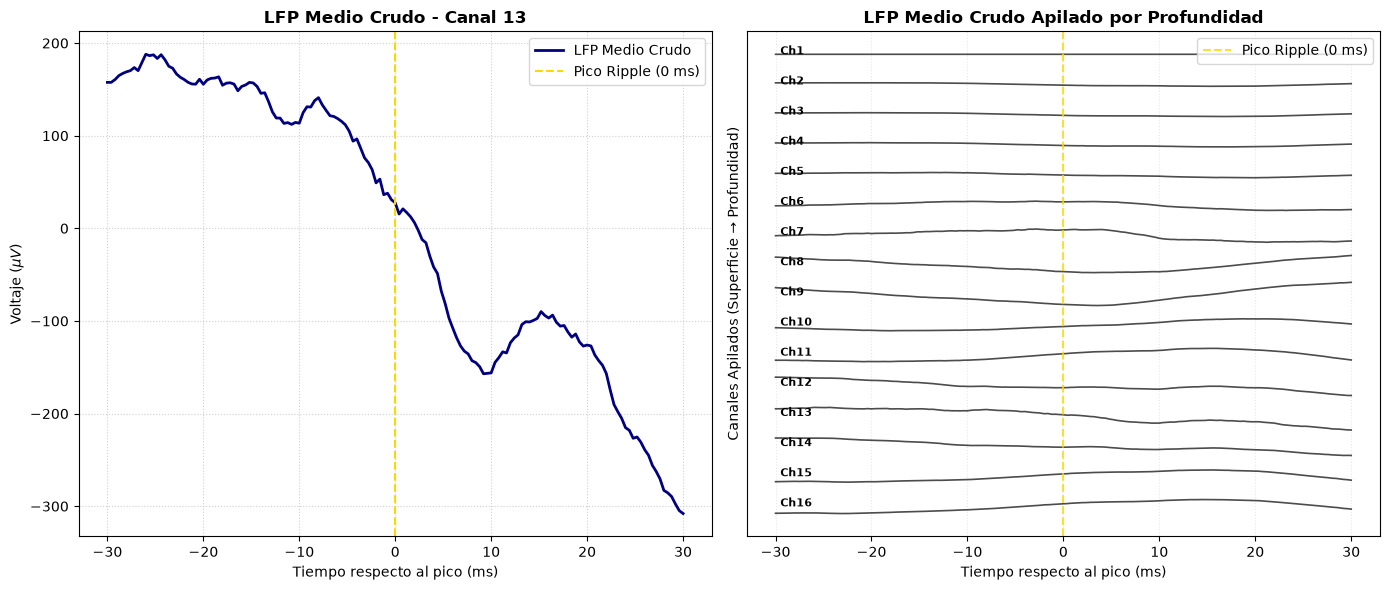

In [ ]:
'''
# =====================================================================
# LFP MEDIO CRUDO APILADO (LIMPIO Y SIN SOLAPAMIENTOS)
# =====================================================================

import matplotlib.pyplot as plt
import numpy as np

# Vector de tiempo (30 ms)
ventana_ms = 30
puntos_ventana = int((ventana_ms / 1000) * fs)
longitud_segmento = (puntos_ventana * 2) + 1
tiempo_ms = np.linspace(-ventana_ms, ventana_ms, longitud_segmento)

plt.figure(figsize=(14, 6))

# --- SUBPLOT 1: LFP CRUDO MEDIO INDIVIDUAL (CANAL 13) ---
plt.subplot(1, 2, 1)

# Centramos la traza en 0 V restando la media
traza_ch13 = ripple_medio[:, 12] - np.mean(ripple_medio[:, 12])

plt.plot(tiempo_ms, traza_ch13, color='navy', linewidth=2, label='LFP Medio Crudo')
plt.axvline(x=0, color='gold', linestyle='--', label='Pico Ripple (0 ms)')
plt.title('LFP Medio Crudo - Canal 13', fontsize=12, fontweight='bold')
plt.xlabel('Tiempo respecto al pico (ms)', fontsize=10)
plt.ylabel('Voltaje ($\mu V$)', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')


# --- SUBPLOT 2: 16 CANALES APILADOS ORDENADOS (SIN SOLAPAR) ---
plt.subplot(1, 2, 2)

# Calculamos la amplitud máxima pico a pico para dar espacio vertical suficiente
amp_max_cruda = np.max(np.ptp(ripple_medio, axis=0))
offset = amp_max_cruda * 1.3  # Factor > 1.0 para evitar que las trazas se crucen

for ch in range(n_channels):
    canal_num = ch + 1
    
    # Traza centrada en su media (sin ganancia exagerada)
    traza = ripple_medio[:, ch] - np.mean(ripple_medio[:, ch])
    traza_desplazada = traza - (ch * offset)
    
    plt.plot(tiempo_ms, traza_desplazada, color='black', alpha=0.7, linewidth=1.2)
    plt.text(-29.5, -ch * offset, f'Ch{canal_num}', fontsize=8, fontweight='bold', color='black')

plt.axvline(x=0, color='gold', linestyle='--', alpha=0.8, label='Pico Ripple (0 ms)')

plt.title('LFP Medio Crudo Apilado por Profundidad', fontsize=12, fontweight='bold')
plt.xlabel('Tiempo respecto al pico (ms)', fontsize=10)
plt.ylabel('Canales Apilados (Superficie → Profundidad)', fontsize=10)
plt.yticks([])  # Ocultamos los valores numéricos del eje Y
plt.grid(True, linestyle=':', alpha=0.3)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

'''

<>:32: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:32: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\natal\AppData\Local\Temp\ipykernel_12928\164823561.py:32: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.ylabel('Voltaje ($\mu V$)', fontsize=10)


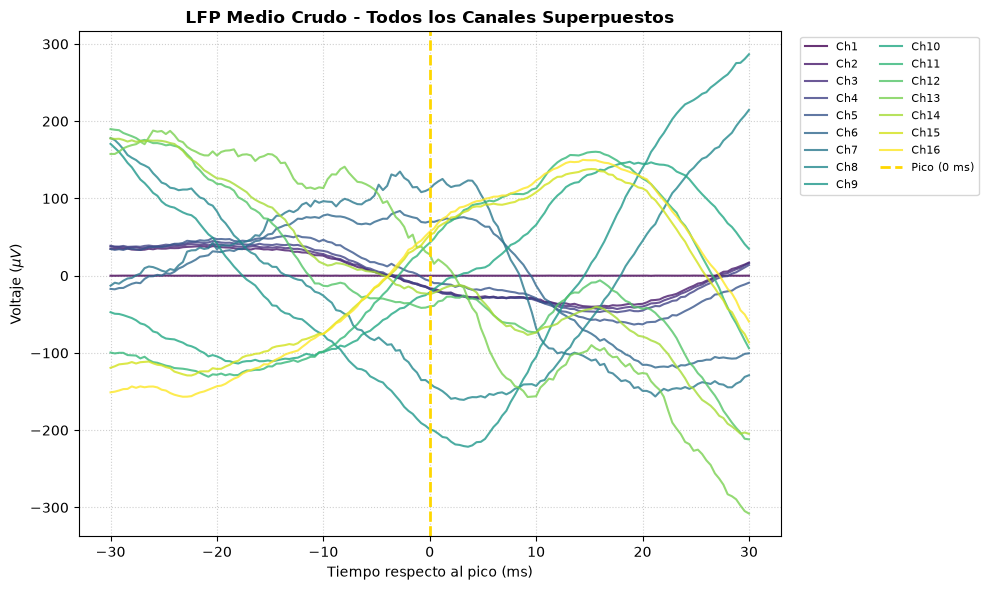

In [ ]:
'''
# =====================================================================
# LFP MEDIO CRUDO - 16 CANALES SUPERPUESTOS EN EL MISMO EJE (µV)
# =====================================================================

import matplotlib.pyplot as plt
import numpy as np

# Vector de tiempo (ventana de 30 ms)
ventana_ms = 30
puntos_ventana = int((ventana_ms / 1000) * fs)
longitud_segmento = (puntos_ventana * 2) + 1
tiempo_ms = np.linspace(-ventana_ms, ventana_ms, longitud_segmento)

plt.figure(figsize=(10, 6))

# Mapa de colores para diferenciar fácilmente cada canal de superficie a profundidad
colores = plt.cm.viridis(np.linspace(0, 1, n_channels))

for ch in range(n_channels):
    canal_num = ch + 1
    
    # Restamos la media para que todos partan del mismo nivel de voltaje en Y
    traza = ripple_medio[:, ch] - np.mean(ripple_medio[:, ch])
    
    plt.plot(tiempo_ms, traza, color=colores[ch], label=f'Ch{canal_num}', alpha=0.8, linewidth=1.5)

# Línea vertical del pico a 0 ms
plt.axvline(x=0, color='gold', linestyle='--', linewidth=2, label='Pico (0 ms)')

plt.title('LFP Medio Crudo - Todos los Canales Superpuestos', fontsize=12, fontweight='bold')
plt.xlabel('Tiempo respecto al pico (ms)', fontsize=10)
plt.ylabel('Voltaje ($\mu V$)', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)

# Leyenda ordenada fuera del gráfico a la derecha para no tapar la onda
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

'''

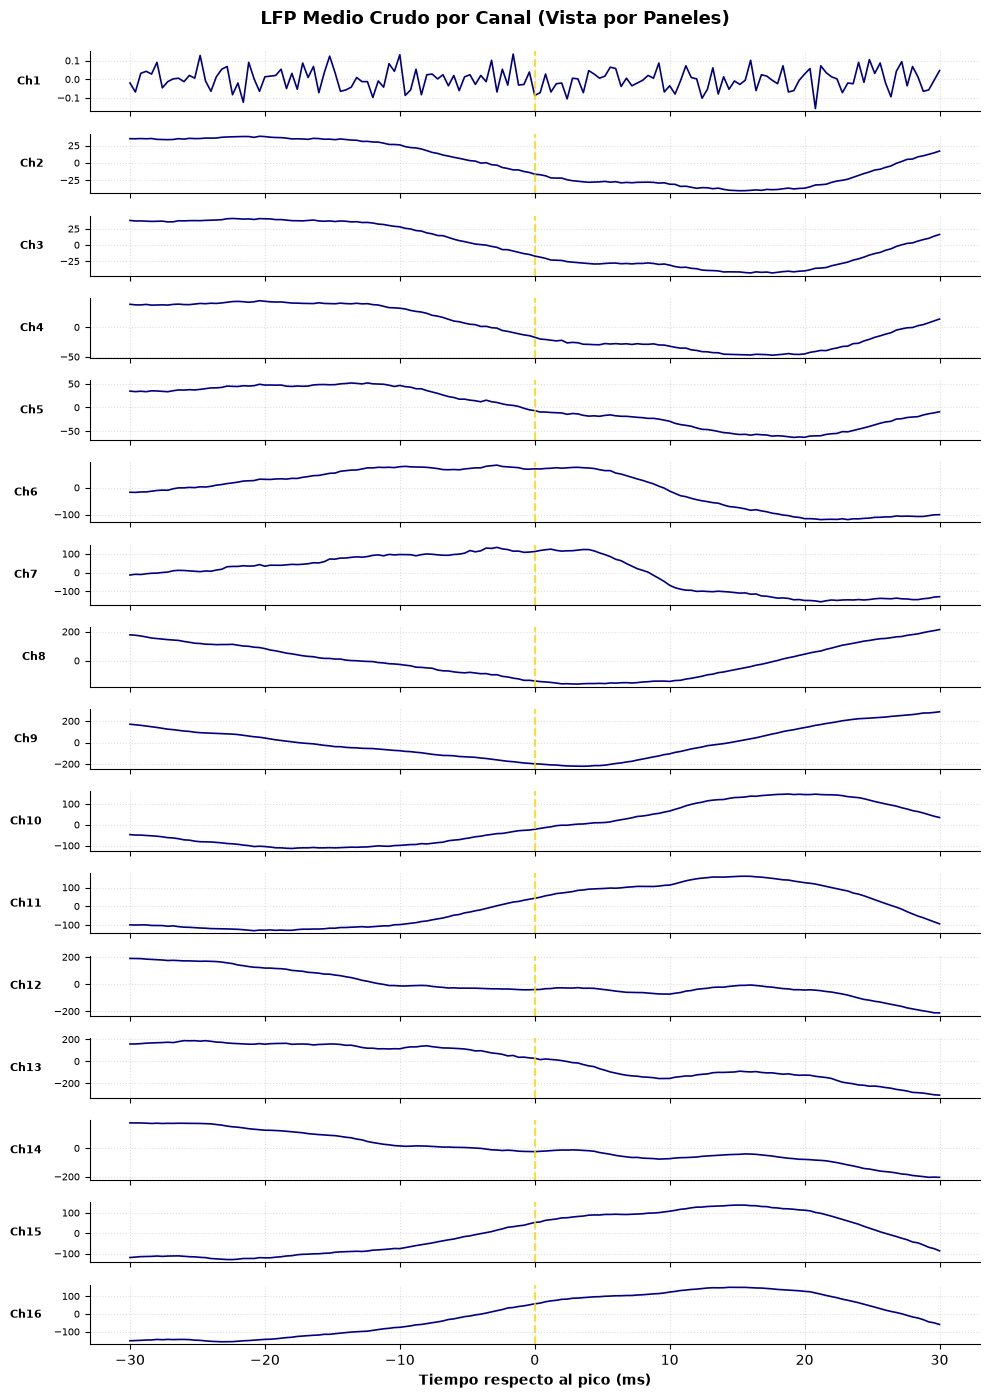

In [ ]:
'''
# =====================================================================
# LFP MEDIO CRUDO - 16 PANALES INDEPENDIENTES (DE CH1 ARRIBA A CH16 ABAJO)
# =====================================================================

import matplotlib.pyplot as plt
import numpy as np

# Vector de tiempo (30 ms)
ventana_ms = 30
puntos_ventana = int((ventana_ms / 1000) * fs)
longitud_segmento = (puntos_ventana * 2) + 1
tiempo_ms = np.linspace(-ventana_ms, ventana_ms, longitud_segmento)

# Creamos 16 subplots apilados verticalmente compartiendo el eje X
fig, axes = plt.subplots(n_channels, 1, figsize=(10, 14), sharex=True)

for ch in range(n_channels):
    ax = axes[ch]
    canal_num = ch + 1
    
    # Traza centrada en 0 uV para ese canal
    traza = ripple_medio[:, ch] - np.mean(ripple_medio[:, ch])
    
    # Graficamos la onda de cada canal en color oscuro neutro
    ax.plot(tiempo_ms, traza, color='navy', linewidth=1.2)
    ax.axvline(x=0, color='gold', linestyle='--', alpha=0.8)
    
    # Etiqueta del canal en el eje Y (a la izquierda)
    ax.set_ylabel(f'Ch{canal_num}', fontsize=8, fontweight='bold', rotation=0, labelpad=20, va='center')
    
    # Ajuste de ticks del eje Y para que no recarguen visualmente
    ax.tick_params(axis='y', labelsize=7)
    ax.grid(True, linestyle=':', alpha=0.4)
    
    # Estética limpia: quitamos bordes superior e derecho
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Etiqueta del eje X solo en la última gráfica de abajo (Canal 16)
axes[-1].set_xlabel('Tiempo respecto al pico (ms)', fontsize=10, fontweight='bold')

# Título general de la figura
fig.suptitle('LFP Medio Crudo por Canal (Vista por Paneles)', fontsize=13, fontweight='bold', y=0.995)

plt.tight_layout()
plt.show()

'''

In [41]:
# 7. FILTRADO EN BANDA RIPPLE Y CÁLCULO DEL RIPPLE POWER 

# Para evitar efectos de borde al hacer la transformada de Fourier, se filtra el LFP continuo, sin ventanas
# Transformada de Hilbert para obtener la envolvente de la señal filtrada en banda ripple

# Banda ripple 
f_low = 100
f_high = 300

# Diseñar un filtro Butterworth de orden 4 y filtrar la matriz LFP
sos = butter(4, [f_low, f_high], btype='band', fs=fs, output='sos')
lfp_ripple_band = sosfiltfilt(sos, datos_matriz, axis=0)

## CÁLCULO DE LA ENVOLVENTE DE HILBERT Y EL RIPPLE POWER ##
envolvente = np.abs(hilbert(lfp_ripple_band, axis=0))
potencia_instantanea = envolvente ** 2  # Potencia instantánea (uV^2)

# Recortar las ventanas de potencia por cada ripple (30 ms)
lista_potencia_ripples = []
lista_ripple_band_cortes = []

for pico in picos_ripples:
    inicio = pico - puntos_ventana
    fin = pico + puntos_ventana + 1
    
    if inicio >= 0 and fin <= puntos_de_tiempo:
        lista_potencia_ripples.append(potencia_instantanea[inicio:fin, :])
        lista_ripple_band_cortes.append(lfp_ripple_band[inicio:fin, :])

matriz_potencia = np.array(lista_potencia_ripples)  # (270 ripples, 151 puntos de tiempo, 16 canales)
matriz_ripple_band = np.array(lista_ripple_band_cortes)

# Ripple medio filtrado
ripple_medio_filtrado = np.mean(matriz_ripple_band, axis=0)

# Ripple poweer medio por canal
power_medio_por_canal = np.mean(matriz_potencia, axis=(0, 1))
# Canal con mayor potencia promedio
canal_max_power = np.argmax(power_medio_por_canal) + 1

# Actualizar el CSV con la potencia promedio por canal
df_resultados['Ripple_Power_Medio'] = power_medio_por_canal
df_resultados.to_csv(ruta_csv, index=False)

print("="*65)
print("Análisis de ripple power completado con éxito")
print(f"Canal con mayor Ripple Power Medio: Canal {canal_max_power}")
print(f"   └─ Potencia media registrada: {power_medio_por_canal[canal_max_power-1]:.2f} uV²")
print(f"Tabla CSV actualizada con 'Ripple_Power_Medio' en:\n{ruta_csv}")
print("="*65)

Análisis de ripple power completado con éxito
Canal con mayor Ripple Power Medio: Canal 7
   └─ Potencia media registrada: 34231.05 uV²
Tabla CSV actualizada con 'Ripple_Power_Medio' en:
D:\Violeta\ANALISIS\WT_90\2025_07_16_0000\ProcesamientoNatalia\amplitud_maxima_por_canal.csv


<>:11: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:11: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\natal\AppData\Local\Temp\ipykernel_12928\1206692028.py:11: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.xlabel('Potencia Media ($\mu V^2$)', fontsize=10)


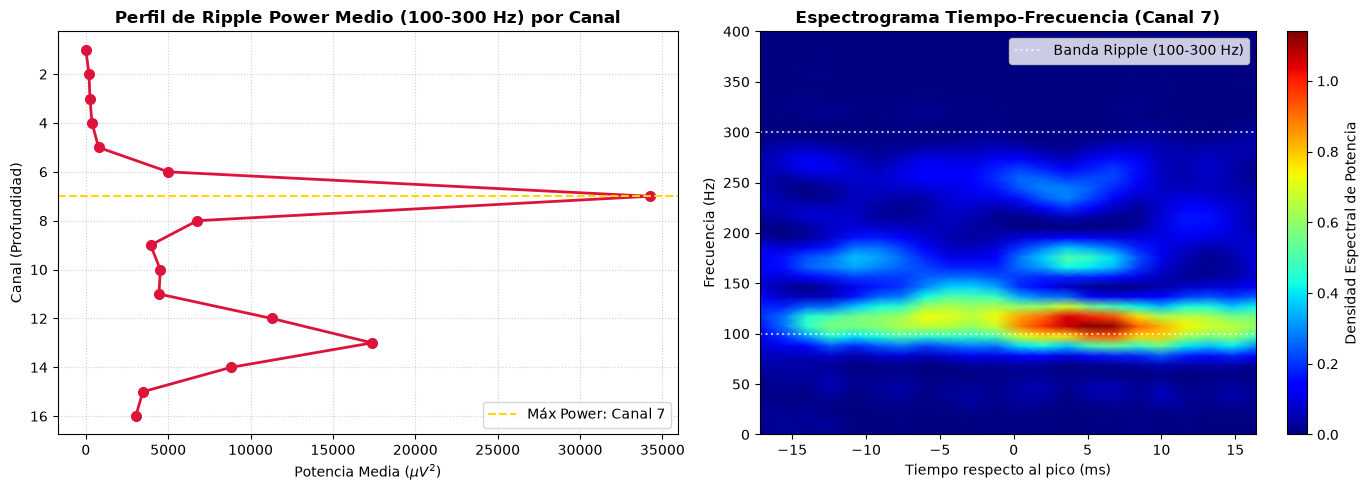

Gráfica guardada en:
D:\Violeta\ANALISIS\WT_90\2025_07_16_0000\ProcesamientoNatalia\ripple_power_y_espectrograma.png


In [42]:
# FIGURA MULTIPANEL (ESPECTROGRAMA + PERFIL DE POTENCIA) 
plt.figure(figsize=(14, 5))

# Subplot A: Perfil de Ripple Power Medio por Canal
plt.subplot(1, 2, 1)
canales_eje = np.arange(1, n_channels + 1)
plt.plot(power_medio_por_canal, canales_eje, 'o-', color='crimson', linewidth=2, markersize=7)
plt.axhline(y=canal_max_power, color='gold', linestyle='--', label=f'Máx Power: Canal {canal_max_power}')
plt.gca().invert_yaxis()  # Invertimos eje Y para simular la profundidad del probe
plt.title('Perfil de Ripple Power Medio (100-300 Hz) por Canal', fontsize=12, fontweight='bold')
plt.xlabel('Potencia Media ($\mu V^2$)', fontsize=10)
plt.ylabel('Canal (Profundidad)', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right')

# Subplot B: Espectrograma Tiempo-Frecuencia del Canal Máximo
plt.subplot(1, 2, 2)
# Extraemos la señal del canal de mayor potencia para calcular su espectrograma medio
señal_espectrograma = ripple_medio_filtrado[:, canal_max_power - 1]

frecuencias, tiempos_spec, Sxx = spectrogram(
    señal_espectrograma, 
    fs=fs, 
    nperseg=64, 
    noverlap=60, 
    nfft=256
)

# Convertimos eje de tiempo a milisegundos centrados en 0 (-30 ms a +30 ms)
tiempos_spec_ms = (tiempos_spec * 1000) - ventana_ms

plt.pcolormesh(tiempos_spec_ms, frecuencias, Sxx, shading='gouraud', cmap='jet')
plt.axhline(y=100, color='white', linestyle=':', alpha=0.7)
plt.axhline(y=300, color='white', linestyle=':', alpha=0.7, label='Banda Ripple (100-300 Hz)')
plt.ylim(0, 400)  # Mostramos de 0 a 400 Hz para ver dónde destaca la potencia
plt.title(f'Espectrograma Tiempo-Frecuencia (Canal {canal_max_power})', fontsize=12, fontweight='bold')
plt.xlabel('Tiempo respecto al pico (ms)', fontsize=10)
plt.ylabel('Frecuencia (Hz)', fontsize=10)
plt.colorbar(label='Densidad Espectral de Potencia')
plt.legend(loc='upper right')

plt.tight_layout()

# Guardar figura en la carpeta ProcesamientoNatalia
ruta_figura_power = carpeta_resultados / "ripple_power_y_espectrograma.png"
plt.savefig(ruta_figura_power, dpi=300)
plt.show()

print(f"Gráfica guardada en:\n{ruta_figura_power}")


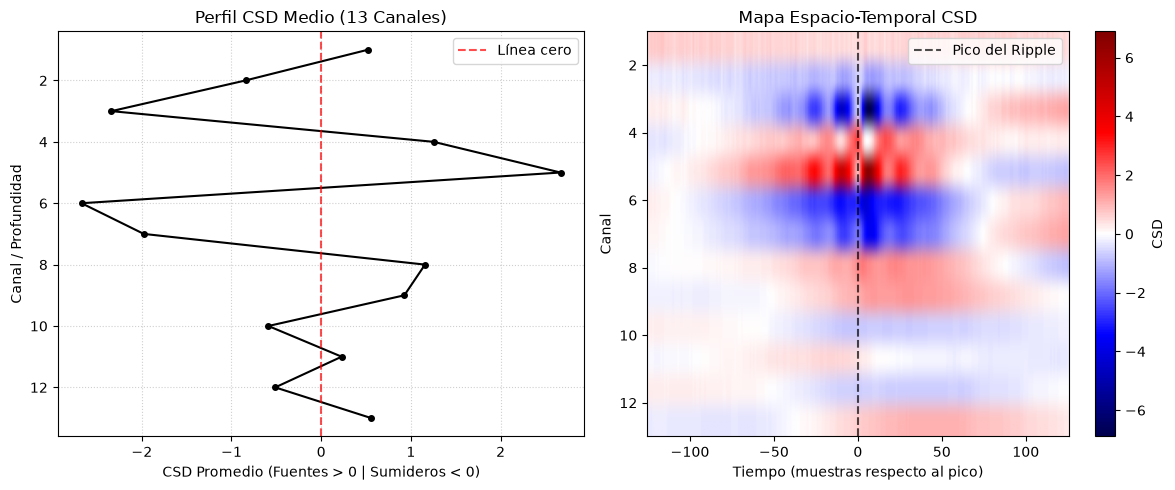

Gráfica guardada en:
D:\Violeta\ANALISIS\WT_90\2025_07_16_0000\ProcesamientoNatalia\perfil_CSD_medio_y_mapa_espacio_temporal_CSD.png


In [56]:
# 8. CÁLCULO DE CSD MEDIO POR CANAL EN EL RIPPLE Y PERFIL VERTICAL 
# Cargar el archivo .dat / .mat
mat_csd = sio.loadmat(archivo_csd)

# Acceder a la estructura 'rippleCSDs'
ripple_struct = mat_csd['rippleCSDs'][0, 0]

# Extraer el vector de tiempo (t) y la matriz 3D (tiempo, canales, nºripples)
tiempo = ripple_struct['t'].flatten()  # Array de tiempo en ms
csd_raw = ripple_struct['CSDs']        # Matriz 3D (251 x 13 x 270)

# Promediar sobre los ripples (eje 2) y transponer (.T)
# Pasar de (tiempo, canales, ripples) -> (tiempo, canales) -> [canales, tiempo]
csd_matrix = np.mean(csd_raw, axis=2).T

# Extraemos las dimensiones dinámicamente (se adapta a cualquier ratón/sesión)
n_canales, n_muestras = csd_matrix.shape

# Definir la ventana central del ripple
centro = n_muestras // 2
ancho_ventana = int(n_muestras * 0.2)  # Ventana alrededor del pico
csd_ventana = csd_matrix[:, centro - ancho_ventana : centro + ancho_ventana]

# Calcular el promedio por canal para el perfil vertical
csd_medio_canal = np.mean(csd_ventana, axis=1)
canales = np.arange(1, n_canales + 1)

# Representación Gráfica
plt.figure(figsize=(12, 5))

# --- Subplot 1: Perfil de Fuentes y Sumideros ---
plt.subplot(1, 2, 1)
plt.plot(csd_medio_canal, canales, '-o', color='black', linewidth=1.5, markersize=4)
plt.axvline(0, color='red', linestyle='--', alpha=0.7, label='Línea cero')
plt.gca().invert_yaxis()  # Canal 1 en la parte superior (superficie)
plt.xlabel('CSD Promedio (Fuentes > 0 | Sumideros < 0)')
plt.ylabel('Canal / Profundidad')
plt.title(f'Perfil CSD Medio ({n_canales} Canales)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

# --- Subplot 2: Mapa Espacio-Temporal 2D ---
plt.subplot(1, 2, 2)
vmax = np.max(np.abs(csd_matrix))  # Escala simétrica para centrar el cero
im = plt.imshow(csd_matrix, aspect='auto', cmap='seismic', vmin=-vmax, vmax=vmax,
                extent=[-n_muestras/2, n_muestras/2, n_canales, 1])

cbar = plt.colorbar(im)
cbar.set_label('CSD')
plt.axvline(0, color='black', linestyle='--', alpha=0.7, label='Pico del Ripple')
plt.xlabel('Tiempo (muestras respecto al pico)')
plt.ylabel('Canal')
plt.title('Mapa Espacio-Temporal CSD')
plt.legend(loc='upper right')

plt.tight_layout()

# Guardar figura en la carpeta ProcesamientoNatalia
ruta_figura_power = carpeta_resultados / "perfil_CSD_medio_y_mapa_espacio_temporal_CSD.png"
plt.savefig(ruta_figura_power, dpi=300)
plt.show()

print(f"Gráfica guardada en:\n{ruta_figura_power}")

C:\Users\natal\AppData\Local\Temp\ipykernel_12928\505800980.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


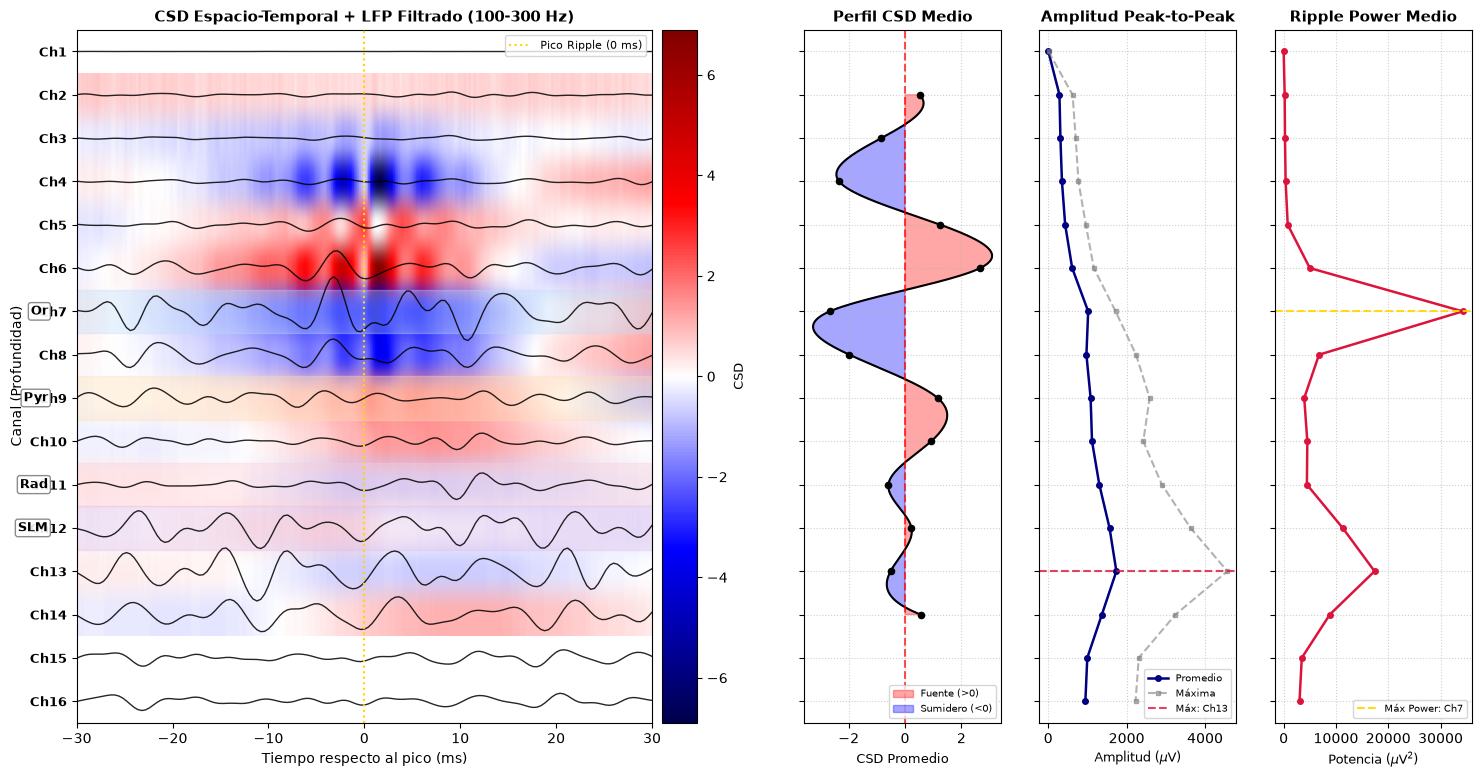

Gráfica guardada correctamente en:
D:\Violeta\ANALISIS\WT_90\2025_07_16_0000\ProcesamientoNatalia\perfil_integrado_ripples_CSD.png


In [ ]:
# ==============================================================================
# CELDA FINAL: FIGURA INTEGRADA CORREGIDA (ALINEACIÓN LIMPIA DE CANALES)
# ==============================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ------------------------------------------------------------------------------
# 1. GESTIÓN DINÁMICA Y CENTRADO DE CANALES (CSD vs LFP)
# ------------------------------------------------------------------------------
n_samples_lfp, n_ch_lfp = ripple_medio_filtrado.shape
canales_lfp = np.arange(1, n_ch_lfp + 1)

n_ch_csd = csd_matrix.shape[0]

# Centrar automáticamente los canales CSD respecto al probe de LFP
# (Ejemplo: si LFP=16 y CSD=13, CSD se ubica en los canales 2 a 14)
ch_offset_csd = (n_ch_lfp - n_ch_csd) // 2
canales_csd = np.arange(1 + ch_offset_csd, n_ch_csd + 1 + ch_offset_csd)

n_ch_amp = len(promedio_indiv_por_canal)
canales_amp = np.arange(1, n_ch_amp + 1)

n_ch_power = len(power_medio_por_canal)
canales_power = np.arange(1, n_ch_power + 1)


# ------------------------------------------------------------------------------
# 2. DETECCIÓN AUTOMÁTICA DE CAPAS
# ------------------------------------------------------------------------------
def clasificar_capas_hipocampo(csd_medio, power_medio):
    n_ch = len(csd_medio)
    
    # Fuentes locales (máximos CSD)
    fuentes_locales = [i for i in range(1, n_ch - 1) if csd_medio[i] > csd_medio[i-1] and csd_medio[i] > csd_medio[i+1]]
    idx_max_power = np.argmax(power_medio)
    
    # Piramidal (Pyr)
    idx_pyr = min(fuentes_locales, key=lambda x: abs(x - idx_max_power)) if fuentes_locales else idx_max_power

    # Radiatum (Rad) -> primer sumidero hacia abajo
    idx_rad = next((i for i in range(idx_pyr + 1, n_ch - 1) if csd_medio[i] < csd_medio[i-1] and csd_medio[i] < csd_medio[i+1]), None)
            
    # SLM -> siguiente fuente hacia abajo de Rad
    idx_slm = next((i for i in range(idx_rad + 1, n_ch - 1) if csd_medio[i] > csd_medio[i-1] and csd_medio[i] > csd_medio[i+1]), None) if idx_rad is not None else None

    # Oriens (Or) -> sumidero estricto hacia arriba
    idx_or = next((i for i in range(idx_pyr - 1, 0, -1) if csd_medio[i] < csd_medio[i+1] and csd_medio[i] < csd_medio[i-1]), None)
            
    return idx_pyr, idx_rad, idx_slm, idx_or

idx_pyr, idx_rad, idx_slm, idx_or = clasificar_capas_hipocampo(csd_medio_canal, power_medio_por_canal)

capas_dibujo = []
indices_capas = [
    (idx_pyr, "Pyr", "#ffe0b2"), 
    (idx_rad, "Rad", "#ffcdd2"), 
    (idx_slm, "SLM", "#e1bee7"), 
    (idx_or, "Or", "#bbdefb")
]

for idx, label, color in indices_capas:
    if idx is not None:
        ch_num = canales_csd[idx]
        capas_dibujo.append((ch_num, label, color))


# ------------------------------------------------------------------------------
# 3. GENERACIÓN DE LA FIGURA MULTI-PANEL
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(
    1, 4, figsize=(18, 9), sharey=True,
    gridspec_kw={'width_ratios': [3.5, 1, 1, 1], 'wspace': 0.12}
)

ax_main, ax_csd_prof, ax_amp, ax_power = axes

# --- SUBPLOT 1: MAPA CSD 2D + LFP FILTRADO (100-300 Hz) ---
vmax = np.max(np.abs(csd_matrix))

y_top = canales_csd[0] - 0.5
y_bottom = canales_csd[-1] + 0.5

im = ax_main.imshow(
    csd_matrix, aspect='auto', cmap='seismic', vmin=-vmax, vmax=vmax,
    extent=[tiempo[0], tiempo[-1], y_bottom, y_top]
)

# Sombras anatómicas y etiquetas fuera a la izquierda
for ch_num, label, color in capas_dibujo:
    ax_main.axhspan(ch_num - 0.5, ch_num + 0.5, color=color, alpha=0.35, zorder=1)
    ax_main.text(
        tiempo[0] - (tiempo[-1] - tiempo[0]) * 0.05, ch_num, label,
        color='black', fontsize=9, fontweight='bold', va='center', ha='right',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='gray', alpha=0.9),
        clip_on=False
    )

# Trazo de LFP Filtrado uniforme (en negro)
amp_oscilacion = np.max(np.abs(ripple_medio_filtrado))
escala_lfp = 0.8 / amp_oscilacion

for ch in range(n_ch_lfp):
    canal_num = ch + 1
    traza_escalada = canal_num - (ripple_medio_filtrado[:, ch] * escala_lfp)
    ax_main.plot(tiempo, traza_escalada, color='black', alpha=0.85, linewidth=1.0, zorder=3)

ax_main.axvline(0, color='gold', linestyle=':', linewidth=1.5, label='Pico Ripple (0 ms)', zorder=4)
ax_main.set_title('CSD Espacio-Temporal + LFP Filtrado (100-300 Hz)', fontsize=11, fontweight='bold')
ax_main.set_xlabel('Tiempo respecto al pico (ms)', fontsize=10)
ax_main.set_ylabel('Canal (Profundidad)', fontsize=10)

# Orden exacto del eje Y: Ch1 arriba (0.5), Ch16 abajo (16.5)
ax_main.set_ylim(n_ch_lfp + 0.5, 0.5)

labels_eje_y = [f'Ch{ch}' for ch in canales_lfp]
ax_main.set_yticks(canales_lfp)
ax_main.set_yticklabels(labels_eje_y, fontsize=9, fontweight='bold')
ax_main.legend(loc='upper right', fontsize=8)

cbar = fig.colorbar(im, ax=ax_main, orientation='vertical', pad=0.015)
cbar.set_label('CSD', fontsize=9)


# --- SUBPLOT 2: PERFIL CSD MEDIO (FUENTES=ROJO / SUMIDEROS=AZUL) ---
f_interp = interp1d(canales_csd, csd_medio_canal, kind='cubic')
canales_finos = np.linspace(canales_csd[0], canales_csd[-1], 300)
csd_fino = f_interp(canales_finos)

ax_csd_prof.plot(csd_fino, canales_finos, color='black', linewidth=1.5)
ax_csd_prof.scatter(csd_medio_canal, canales_csd, color='black', s=20, zorder=5)
ax_csd_prof.axvline(0, color='red', linestyle='--', alpha=0.7)

# Fuente (> 0) = Rojo | Sumidero (< 0) = Azul
ax_csd_prof.fill_betweenx(canales_finos, csd_fino, 0, where=(csd_fino > 0), color='red', alpha=0.35, label='Fuente (>0)')
ax_csd_prof.fill_betweenx(canales_finos, csd_fino, 0, where=(csd_fino < 0), color='blue', alpha=0.35, label='Sumidero (<0)')

ax_csd_prof.set_title('Perfil CSD Medio', fontsize=11, fontweight='bold')
ax_csd_prof.set_xlabel('CSD Promedio', fontsize=9)
ax_csd_prof.grid(True, linestyle=':', alpha=0.6)
ax_csd_prof.legend(loc='lower right', fontsize=7)


# --- SUBPLOT 3: PERFIL DE AMPLITUD PICO A PICO ---
ax_amp.plot(promedio_indiv_por_canal, canales_amp, 'o-', color='navy', linewidth=1.8, markersize=4, label='Promedio')
ax_amp.plot(max_absoluta_por_canal, canales_amp, 's--', color='gray', alpha=0.6, markersize=3, label='Máxima')
ax_amp.axhline(y=canal_top_amp, color='crimson', linestyle='--', alpha=0.8, label=f'Máx: Ch{canal_top_amp}')

ax_amp.set_title('Amplitud Peak-to-Peak', fontsize=11, fontweight='bold')
ax_amp.set_xlabel(r'Amplitud ($\mu$V)', fontsize=9)
ax_amp.grid(True, linestyle=':', alpha=0.6)
ax_amp.legend(loc='lower right', fontsize=7)


# --- SUBPLOT 4: PERFIL DE RIPPLE POWER MEDIO ---
ax_power.plot(power_medio_por_canal, canales_power, 'o-', color='crimson', linewidth=1.8, markersize=4)
ax_power.axhline(y=canal_max_power, color='gold', linestyle='--', alpha=0.9, label=f'Máx Power: Ch{canal_max_power}')

ax_power.set_title('Ripple Power Medio', fontsize=11, fontweight='bold')
ax_power.set_xlabel(r'Potencia ($\mu$V$^2$)', fontsize=9)
ax_power.grid(True, linestyle=':', alpha=0.6)
ax_power.legend(loc='lower right', fontsize=7)


# Guardar figura final
ruta_figura_final = carpeta_resultados / "perfil_integrado_ripples_CSD.png"
plt.savefig(ruta_figura_final, dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

print(f"Gráfica guardada correctamente en:\n{ruta_figura_final}")